# Scoring 04 - Report Table and Figure Exports

Final report-export stage. This notebook reads the canonical `Code 1.0/artifacts` outputs and writes only thesis-ready tables and required figures to `artifacts/report_outputs/`.

It does not retune, reselect, or alter the modelling artifacts. Exploratory tables and charts in the earlier notebooks remain display-only.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression

# Support both normal notebook execution from Scoring/ and scripted execution from the repo root.
ARTIFACTS = Path('../artifacts')
if not (ARTIFACTS / 'tuned_params.json').exists():
    ARTIFACTS = Path('Code 1.0/artifacts')
assert (ARTIFACTS / 'tuned_params.json').exists(), 'Cannot locate Code 1.0 artifacts folder.'

OUTPUT = ARTIFACTS / 'report_outputs'
TABLES_DIR = OUTPUT / 'tables'
FIGURES_DIR = OUTPUT / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Keep the report output folder exact on rerun: remove only generated report asset types.
for folder, suffixes in ((TABLES_DIR, {'.csv', '.md'}), (FIGURES_DIR, {'.png'})):
    for path in folder.iterdir():
        if path.is_file() and path.suffix.lower() in suffixes:
            path.unlink()

tuned = json.loads((ARTIFACTS / 'tuned_params.json').read_text())
calibration = json.loads((ARTIFACTS / 'calibration.json').read_text())
thresholds = json.loads((ARTIFACTS / 'thresholds.json').read_text())
test_results = json.loads((ARTIFACTS / 'test_results.json').read_text())
subgroup_results = json.loads((ARTIFACTS / 'subgroup_results.json').read_text())

FAMILY_ORDER = ['logreg', 'rf', 'xgb']
CONFIG_ORDER = ['A', 'B', 'C']
COST_RATIOS = [5, 10, 20]
SELECTED = tuned['selected']
MODEL_LABELS = {'logreg_C': 'LR-C', 'rf_C': 'RF-C', 'xgb_C': 'XGB-C'}
FAMILY_LABELS = {'logreg': 'LR', 'rf': 'RF', 'xgb': 'XGB'}
POLICY_LABELS = {
    'naive': 'Naive 0.5',
    'f1': 'F1-optimal',
    'cost_5': 'Cost-optimal (r = 5)',
    'cost_10': 'Cost-optimal (r = 10)',
    'cost_20': 'Cost-optimal (r = 20)',
}
print('writing report assets to:', OUTPUT.resolve())

writing report assets to: C:\Users\cavan\ARCHIVE\Thesis\Code 1.0\artifacts\report_outputs


In [2]:
def model_label(key):
    if key in MODEL_LABELS:
        return MODEL_LABELS[key]
    family, cfg = key.split('_')
    return f'{FAMILY_LABELS[family]}-{cfg}'


def fmt_fixed(x, digits=3):
    if x is None or pd.isna(x):
        return '--'
    return f'{float(x):.{digits}f}'


def fmt_trim(x, max_digits=4):
    if x is None or pd.isna(x):
        return '--'
    text = f'{float(x):.{max_digits}f}'.rstrip('0').rstrip('.')
    return text if text else '0'


def fmt_ci(point, lo, hi, digits=3):
    return f'{point:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]'


def fmt_count(x):
    return f'{int(x):,}'


def escape_md(value):
    text = str(value)
    return text.replace('|', '\\|').replace('\n', '<br>')


def markdown_table(df):
    rendered = df.astype(str)
    header = '| ' + ' | '.join(escape_md(c) for c in rendered.columns) + ' |'
    sep = '| ' + ' | '.join('---' for _ in rendered.columns) + ' |'
    rows = [
        '| ' + ' | '.join(escape_md(v) for v in row) + ' |'
        for row in rendered.to_numpy()
    ]
    return '\n'.join([header, sep, *rows])


def export_table(name, csv_df, md_df, caption):
    csv_path = TABLES_DIR / f'{name}.csv'
    md_path = TABLES_DIR / f'{name}.md'
    csv_df.to_csv(csv_path, index=False)
    md_path.write_text(f'{caption}\n\n{markdown_table(md_df)}\n', encoding='utf-8')
    return csv_path, md_path


def top2_overlap(rows, value_col, lo_col, hi_col, ascending):
    ordered = rows.sort_values(value_col, ascending=ascending)
    first, second = ordered.iloc[0], ordered.iloc[1]
    return bool(max(first[lo_col], second[lo_col]) <= min(first[hi_col], second[hi_col]))


def confusion_at(y, p, t):
    predicted_default = p >= t
    tp = int(np.sum((y == 1) & predicted_default))
    fn = int(np.sum((y == 1) & ~predicted_default))
    fp = int(np.sum((y == 0) & predicted_default))
    tn = int(np.sum((y == 0) & ~predicted_default))
    return {'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}


def apply_selected_calibrator(key, raw_scores, calibrators):
    method = calibration['selected_calibrator'][key]
    calibrator = calibrators[key]
    if method == 'platt':
        p = calibrator.predict_proba(raw_scores.reshape(-1, 1))[:, 1]
    else:
        p = np.asarray(calibrator.predict(raw_scores)).ravel()
    return np.clip(p, 0.0, 1.0)

In [3]:
# Table 1: validation discrimination for all nine pipelines.
validation = pd.DataFrame(tuned['validation_metrics'])
validation['family'] = validation['pipeline'].str.split('_').str[0]
validation['config'] = validation['pipeline'].str.split('_').str[1]
validation['family_order'] = validation['family'].map({f: i for i, f in enumerate(FAMILY_ORDER)})
validation['config_order'] = validation['config'].map({c: i for i, c in enumerate(CONFIG_ORDER)})
validation = validation.sort_values(['family_order', 'config_order']).reset_index(drop=True)

table1_csv = validation[[
    'pipeline', 'cv_pr_auc', 'val_pr_auc', 'pr_lo', 'pr_hi', 'val_auroc', 'auc_lo', 'auc_hi'
]].copy()
table1_csv.insert(0, 'model', validation['pipeline'].map(model_label))

table1_md = pd.DataFrame({
    'Pipeline': validation['pipeline'].map(model_label),
    'CV PR-AUC': validation['cv_pr_auc'].map(lambda x: fmt_fixed(x, 3)),
    'Val PR-AUC [95% CI]': validation.apply(lambda r: fmt_ci(r.val_pr_auc, r.pr_lo, r.pr_hi, 3), axis=1),
    'Val AUROC [95% CI]': validation.apply(lambda r: fmt_ci(r.val_auroc, r.auc_lo, r.auc_hi, 3), axis=1),
})
export_table(
    'table_01_validation_discrimination',
    table1_csv,
    table1_md,
    'Table 1. Validation discrimination across nine pipeline configurations. PR-AUC = area under the precision-recall curve; AUROC = area under the receiver operating characteristic curve; CIs = 95% paired bootstrap confidence intervals.'
)
table1_md

,Pipeline,CV PR-AUC,Val PR-AUC [95% CI],Val AUROC [95% CI]
0,LR-A,0.351,"0.351 [0.328, 0.374]","0.820 [0.809, 0.830]"
1,LR-B,0.373,"0.369 [0.347, 0.393]","0.850 [0.841, 0.858]"
2,LR-C,0.379,"0.379 [0.358, 0.402]","0.857 [0.848, 0.865]"
3,RF-A,0.393,"0.386 [0.365, 0.410]","0.864 [0.856, 0.872]"
4,RF-B,0.390,"0.384 [0.363, 0.409]","0.863 [0.854, 0.871]"
5,RF-C,0.394,"0.390 [0.368, 0.415]","0.863 [0.855, 0.871]"
6,XGB-A,0.396,"0.389 [0.366, 0.412]","0.864 [0.855, 0.872]"
7,XGB-B,0.394,"0.388 [0.365, 0.411]","0.862 [0.854, 0.871]"
8,XGB-C,0.397,"0.393 [0.370, 0.417]","0.863 [0.855, 0.871]"


In [4]:
# Table 2: validation calibration, selected calibrator per final model.
decomp = pd.DataFrame(calibration['decomposition'])
rows_csv, rows_md = [], []
for family in FAMILY_ORDER:
    key = SELECTED[family]
    selected_method = calibration['selected_calibrator'][key]
    uncal = decomp[(decomp.model == key) & (decomp.variant == 'uncalibrated')].iloc[0]
    cal = decomp[(decomp.model == key) & (decomp.variant == selected_method)].iloc[0]
    rows_csv.append({
        'model': model_label(key),
        'model_key': key,
        'uncalibrated_reliability': uncal.reliability,
        'selected_calibrator': selected_method,
        'calibrated_brier': cal.brier,
        'calibrated_reliability': cal.reliability,
    })
    rows_md.append({
        'Model': model_label(key),
        'Uncal. reliability': fmt_fixed(uncal.reliability, 4),
        'Selected calibrator': selected_method.capitalize(),
        'Calibrated Brier': fmt_fixed(cal.brier, 4),
        'Calibrated reliability': fmt_fixed(cal.reliability, 5),
    })
table2_csv = pd.DataFrame(rows_csv)
table2_md = pd.DataFrame(rows_md)
export_table(
    'table_02_validation_calibration',
    table2_csv,
    table2_md,
    'Table 2. Calibration on the validation-evaluation split. Reliability is the CORP Brier reliability component; lower values indicate better probability calibration.'
)
table2_md

,Model,Uncal. reliability,Selected calibrator,Calibrated Brier,Calibrated reliability
0,LR-C,0.0963,Beta,0.0499,0.00044
1,RF-C,0.0855,Beta,0.0494,0.00037
2,XGB-C,0.0942,Isotonic,0.0496,0.00033


In [5]:
# Table 3: optimized thresholds.
rows_csv, rows_md = [], []
for family in FAMILY_ORDER:
    key = SELECTED[family]
    row = {
        'model': model_label(key),
        'model_key': key,
        'f1_optimal': thresholds[key]['f1'],
        'ratio_5': thresholds[key]['cost_optimal']['5'],
        'ratio_10': thresholds[key]['cost_optimal']['10'],
        'ratio_20': thresholds[key]['cost_optimal']['20'],
    }
    rows_csv.append(row)
    rows_md.append({
        'Model': row['model'],
        'F1-optimal': fmt_trim(row['f1_optimal']),
        'Ratio 5': fmt_trim(row['ratio_5']),
        'Ratio 10': fmt_trim(row['ratio_10']),
        'Ratio 20': fmt_trim(row['ratio_20']),
    })
first_key = SELECTED[FAMILY_ORDER[0]]
theoretical = {str(r): thresholds[first_key]['theoretical'][str(r)]['t_star'] for r in COST_RATIOS}
rows_csv.append({
    'model': 'Closed-form 1/(1+r)',
    'model_key': '',
    'f1_optimal': np.nan,
    'ratio_5': theoretical['5'],
    'ratio_10': theoretical['10'],
    'ratio_20': theoretical['20'],
})
rows_md.append({
    'Model': 'Closed-form 1/(1+r)',
    'F1-optimal': '--',
    'Ratio 5': fmt_fixed(theoretical['5'], 3),
    'Ratio 10': fmt_fixed(theoretical['10'], 3),
    'Ratio 20': fmt_fixed(theoretical['20'], 3),
})
table3_csv = pd.DataFrame(rows_csv)
table3_md = pd.DataFrame(rows_md)
export_table(
    'table_03_thresholds',
    table3_csv,
    table3_md,
    'Table 3. Optimized decision thresholds on the validation-evaluation split. Ratio columns use CFN/CFP; the final row reports the closed-form threshold 1/(1+r).'
)
table3_md

,Model,F1-optimal,Ratio 5,Ratio 10,Ratio 20
0,LR-C,0.19,0.172,0.088,0.055
1,RF-C,0.24,0.172,0.086,0.0476
2,XGB-C,0.23,0.149,0.084,0.039
3,Closed-form 1/(1+r),--,0.167,0.091,0.048


In [6]:
# Table 4: held-out test metrics plus own cost-optimal expected loss.
disc = pd.DataFrame(test_results['discrimination']).set_index('model')
calib = pd.DataFrame(test_results['calibration']).set_index('model')
cost = pd.DataFrame(test_results['cost_table'])
rows_csv, rows_md = [], []
for family in FAMILY_ORDER:
    key = SELECTED[family]
    d = disc.loc[key]
    c = calib.loc[key]
    row = {
        'model': model_label(key),
        'model_key': key,
        'AUROC': d.AUROC,
        'AUROC_lo': d.AUROC_lo,
        'AUROC_hi': d.AUROC_hi,
        'PR_AUC': d.PR_AUC,
        'PR_lo': d.PR_lo,
        'PR_hi': d.PR_hi,
        'reliability': c.reliability,
        'reliability_lo': c.reliability_lo,
        'reliability_hi': c.reliability_hi,
    }
    md_row = {
        'Model': model_label(key),
        'AUROC [95% CI]': fmt_ci(d.AUROC, d.AUROC_lo, d.AUROC_hi, 3),
        'PR-AUC [95% CI]': fmt_ci(d.PR_AUC, d.PR_lo, d.PR_hi, 3),
        'Reliability [95% CI]': fmt_ci(c.reliability, c.reliability_lo, c.reliability_hi, 6),
    }
    for ratio in COST_RATIOS:
        own = cost[(cost.model == key) & (cost.policy == f'cost_{ratio}')].iloc[0]
        row[f'EL_at_{ratio}'] = own[f'EL@{ratio}']
        row[f'EL_at_{ratio}_lo'] = own[f'EL@{ratio}_lo']
        row[f'EL_at_{ratio}_hi'] = own[f'EL@{ratio}_hi']
        md_row[f'EL@{ratio} [95% CI]'] = fmt_ci(own[f'EL@{ratio}'], own[f'EL@{ratio}_lo'], own[f'EL@{ratio}_hi'], 3)
    rows_csv.append(row)
    rows_md.append(md_row)
table4_csv = pd.DataFrame(rows_csv)
table4_md = pd.DataFrame(rows_md)
export_table(
    'table_04_test_metrics_expected_loss',
    table4_csv,
    table4_md,
    "Table 4. Held-out test discrimination, calibration, and expected loss. Expected loss is measured at each model\'s own cost-optimal threshold for the stated CFN/CFP ratio; CIs = 95% paired bootstrap confidence intervals."
)
table4_md

,Model,AUROC [95% CI],PR-AUC [95% CI],Reliability [95% CI],EL@5 [95% CI],EL@10 [95% CI],EL@20 [95% CI]
0,LR-C,"0.859 [0.850, 0.868]","0.405 [0.381, 0.427]","0.000363 [0.000403, 0.000617]","0.215 [0.205, 0.224]","0.338 [0.321, 0.353]","0.485 [0.459, 0.512]"
1,RF-C,"0.864 [0.856, 0.872]","0.408 [0.385, 0.429]","0.000342 [0.000410, 0.000610]","0.214 [0.204, 0.223]","0.326 [0.311, 0.342]","0.484 [0.460, 0.506]"
2,XGB-C,"0.862 [0.854, 0.870]","0.394 [0.372, 0.416]","0.000216 [0.000209, 0.000471]","0.215 [0.206, 0.224]","0.335 [0.319, 0.349]","0.485 [0.462, 0.506]"


In [7]:
# Table 5: ranking matrix.
metric_specs = []
metric_specs.append(('AUROC (discrimination)', disc.reset_index(), 'AUROC', 'AUROC_lo', 'AUROC_hi', False))
metric_specs.append(('PR-AUC (discrimination)', disc.reset_index(), 'PR_AUC', 'PR_lo', 'PR_hi', False))
metric_specs.append(('Reliability (calibration)', calib.reset_index(), 'reliability', 'reliability_lo', 'reliability_hi', True))
for ratio in COST_RATIOS:
    own = cost[cost.policy == f'cost_{ratio}'][['model', f'EL@{ratio}', f'EL@{ratio}_lo', f'EL@{ratio}_hi']].copy()
    metric_specs.append((f'Expected loss @ ratio {ratio}', own, f'EL@{ratio}', f'EL@{ratio}_lo', f'EL@{ratio}_hi', True))

rows_csv, rows_md = [], []
for metric, data, value_col, lo_col, hi_col, ascending in metric_specs:
    ordered = data.sort_values(value_col, ascending=ascending).reset_index(drop=True)
    ranked = [model_label(k) for k in ordered['model'].tolist()]
    overlap = top2_overlap(data, value_col, lo_col, hi_col, ascending)
    rows_csv.append({
        'selection_metric': metric,
        'rank_1': ranked[0],
        'rank_2': ranked[1],
        'rank_3': ranked[2],
        'rank_1_vs_2_ci_overlap': overlap,
    })
    rows_md.append({
        'Selection metric': metric,
        '1st': ranked[0],
        '2nd': ranked[1],
        '3rd': ranked[2],
        'Top-2 CIs overlap': 'Yes' if overlap else 'No',
    })
table5_csv = pd.DataFrame(rows_csv)
table5_md = pd.DataFrame(rows_md)
export_table(
    'table_05_metric_rankings',
    table5_csv,
    table5_md,
    'Table 5. Model ranking by selection metric. Top-2 CI overlap indicates whether the first- and second-ranked models have overlapping 95% intervals for that metric.'
)
table5_md

,Selection metric,1st,2nd,3rd,Top-2 CIs overlap
0,AUROC (discrimination),RF-C,XGB-C,LR-C,Yes
1,PR-AUC (discrimination),RF-C,LR-C,XGB-C,Yes
2,Reliability (calibration),XGB-C,RF-C,LR-C,Yes
3,Expected loss @ ratio 5,RF-C,LR-C,XGB-C,Yes
4,Expected loss @ ratio 10,RF-C,XGB-C,LR-C,Yes
5,Expected loss @ ratio 20,RF-C,LR-C,XGB-C,Yes


In [8]:
# Table 6: XGBoost intersection vs complement approval rates.
tier2 = pd.DataFrame(subgroup_results['tier2'])
xgb_tier2 = tier2[tier2.model == 'xgb_C']
policy_order = ['naive', 'f1', 'cost_5', 'cost_10', 'cost_20']
rows_csv, rows_md = [], []
for policy in policy_order:
    inter = xgb_tier2[(xgb_tier2.group == 'intersection') & (xgb_tier2.policy == policy)].iloc[0]
    comp = xgb_tier2[(xgb_tier2.group == 'complement') & (xgb_tier2.policy == policy)].iloc[0]
    gap_pp = 100 * (inter.approval_rate - comp.approval_rate)
    rows_csv.append({
        'policy': policy,
        'threshold': inter.threshold,
        'intersection_n': int(inter.n),
        'complement_n': int(comp.n),
        'intersection_approval_rate': inter.approval_rate,
        'intersection_approval_rate_lo': inter.approval_rate_lo,
        'intersection_approval_rate_hi': inter.approval_rate_hi,
        'complement_approval_rate': comp.approval_rate,
        'complement_approval_rate_lo': comp.approval_rate_lo,
        'complement_approval_rate_hi': comp.approval_rate_hi,
        'gap_pp': gap_pp,
    })
    rows_md.append({
        'Threshold policy': POLICY_LABELS[policy],
        'Intersection approval [95% CI]': fmt_ci(inter.approval_rate, inter.approval_rate_lo, inter.approval_rate_hi, 3),
        'Complement approval [95% CI]': fmt_ci(comp.approval_rate, comp.approval_rate_lo, comp.approval_rate_hi, 3),
        'Gap (pp)': fmt_fixed(gap_pp, 1),
    })
table6_csv = pd.DataFrame(rows_csv)
table6_md = pd.DataFrame(rows_md)
export_table(
    'table_06_xgb_subgroup_approval',
    table6_csv,
    table6_md,
    'Table 6. Approval rate by threshold policy for the XGBoost model, comparing the vulnerable intersection group with its complement. Gap is intersection minus complement in percentage points.'
)
table6_md

,Threshold policy,Intersection approval [95% CI],Complement approval [95% CI],Gap (pp)
0,Naive 0.5,"0.966 [0.951, 0.980]","0.988 [0.986, 0.989]",-2.1
1,F1-optimal,"0.779 [0.746, 0.811]","0.927 [0.924, 0.930]",-14.8
2,Cost-optimal (r = 5),"0.643 [0.606, 0.678]","0.885 [0.882, 0.889]",-24.2
3,Cost-optimal (r = 10),"0.419 [0.375, 0.458]","0.795 [0.790, 0.799]",-37.5
4,Cost-optimal (r = 20),"0.290 [0.253, 0.325]","0.661 [0.655, 0.666]",-37.1


In [9]:
# Appendix tier-1 subgroup tables.
dimension_names = {'age_group': 'age', 'income_group': 'income', 'dependents_group': 'dependents'}
appendix_order = [
    ('age_group', 'logreg_C'), ('age_group', 'rf_C'), ('age_group', 'xgb_C'),
    ('income_group', 'logreg_C'), ('income_group', 'rf_C'), ('income_group', 'xgb_C'),
    ('dependents_group', 'logreg_C'), ('dependents_group', 'rf_C'), ('dependents_group', 'xgb_C'),
]
tier1_lookup = {(entry['dimension'], entry['model']): pd.DataFrame(entry['table'])
                for entry in subgroup_results['tier1']}
for idx, (dimension, key) in enumerate(appendix_order, start=1):
    raw = tier1_lookup[(dimension, key)].copy()
    raw.insert(0, 'dimension', dimension)
    raw.insert(1, 'model', key)
    md = pd.DataFrame({
        'Group': tier1_lookup[(dimension, key)]['group'],
        'Policy': tier1_lookup[(dimension, key)]['policy'].map(POLICY_LABELS),
        'Threshold': tier1_lookup[(dimension, key)]['threshold'].map(fmt_trim),
        'n': tier1_lookup[(dimension, key)]['n'].map(fmt_count),
        'Approval': tier1_lookup[(dimension, key)]['approval_rate'].map(lambda x: fmt_fixed(x, 3)),
        'FNR': tier1_lookup[(dimension, key)]['fnr'].map(lambda x: fmt_fixed(x, 3)),
        'FPR': tier1_lookup[(dimension, key)]['fpr'].map(lambda x: fmt_fixed(x, 3)),
        'EL': tier1_lookup[(dimension, key)]['EL'].map(lambda x: fmt_fixed(x, 3)),
    })
    short_dim = dimension_names[dimension]
    name = f'appendix_table_{idx:02d}_tier1_{short_dim}_{key}'
    caption = f'Appendix Table {idx}. Tier-1 {short_dim} subgroup decision metrics for {model_label(key)}. EL = expected loss using ratio 10 for naive/F1 policies and the matching ratio for cost-optimal policies.'
    export_table(name, raw, md, caption)
print('exported tier-1 appendix tables:', len(appendix_order))

exported tier-1 appendix tables: 9


In [10]:
# Load final models/calibrators and compute calibrated probabilities for validation-evaluation and test rows.
models = {key: joblib.load(ARTIFACTS / 'models' / f'{key}.joblib') for key in SELECTED.values()}
calibrators = {key: joblib.load(ARTIFACTS / 'calibrators' / f'{key}.joblib') for key in SELECTED.values()}

def model_matrix(split, key):
    cfg = key.split('_')[1]
    return pd.read_parquet(ARTIFACTS / f'{split}_config{cfg}.parquet')

# Validation-evaluation probabilities for Figure 2.
eval_idx = np.array(calibration['val_eval_idx'])
val_eval = {}
for family in FAMILY_ORDER:
    key = SELECTED[family]
    val_df = model_matrix('val', key)
    y_val_eval = val_df['target'].to_numpy()[eval_idx]
    X_val_eval = val_df.drop(columns='target').iloc[eval_idx]
    raw = models[key].predict_proba(X_val_eval)[:, 1]
    val_eval[key] = {
        'y': y_val_eval,
        'raw': raw,
        'calibrated': apply_selected_calibrator(key, raw, calibrators),
    }

# Test probabilities for Figure 3 and confusion counts.
y_test = pd.read_parquet(ARTIFACTS / 'test_configA.parquet')['target'].to_numpy()
test_probabilities = {}
for family in FAMILY_ORDER:
    key = SELECTED[family]
    test_df = model_matrix('test', key)
    X_test = test_df.drop(columns='target')
    raw = models[key].predict_proba(X_test)[:, 1]
    test_probabilities[key] = apply_selected_calibrator(key, raw, calibrators)
print(f'test rows: {len(y_test):,}; default rate: {y_test.mean():.4%}')

test rows: 29,879; default rate: 6.7004%


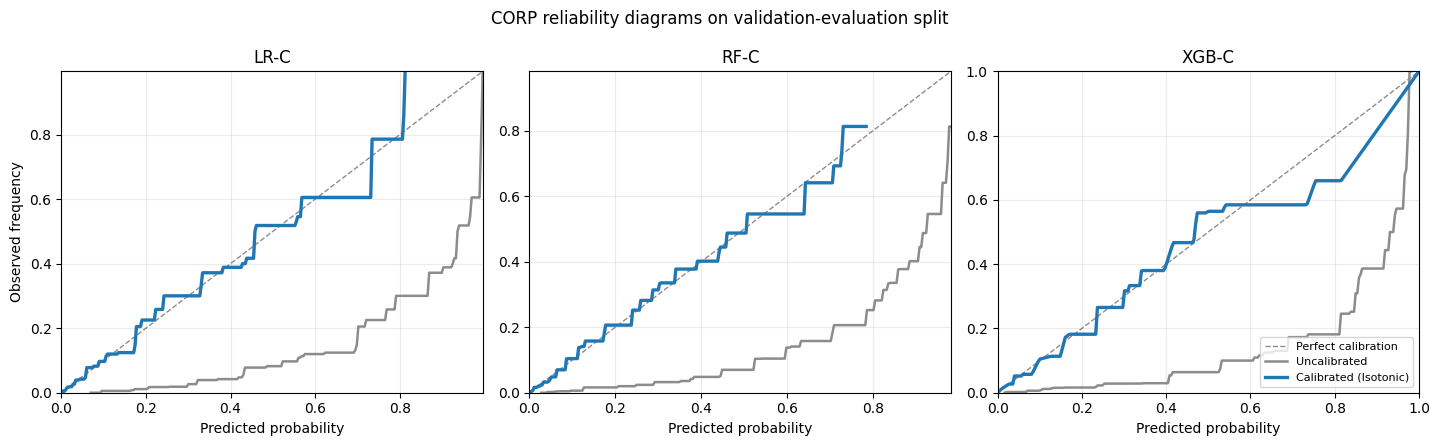

In [11]:
# Figure 2: CORP reliability diagrams, uncalibrated vs selected calibrated.
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5), sharey=False)
for ax, family in zip(axes, FAMILY_ORDER):
    key = SELECTED[family]
    y = val_eval[key]['y']
    curves = [
        ('Uncalibrated', val_eval[key]['raw'], '#8C8C8C', 1.8),
        (f'Calibrated ({calibration["selected_calibrator"][key].capitalize()})',
         val_eval[key]['calibrated'], '#1F77B4', 2.4),
    ]
    limit = max(0.05, *(float(np.max(p)) for _, p, _, _ in curves))
    ax.plot([0, limit], [0, limit], color='black', linestyle='--', alpha=0.45, linewidth=1.0, label='Perfect calibration')
    for label, p, color, width in curves:
        smoother = IsotonicRegression(out_of_bounds='clip').fit(p, y)
        xs = np.linspace(float(np.min(p)), float(np.max(p)), 250)
        ax.plot(xs, smoother.predict(xs), color=color, linewidth=width, label=label)
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_title(model_label(key))
    ax.set_xlabel('Predicted probability')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Observed frequency')
axes[-1].legend(fontsize=8, loc='lower right')
fig.suptitle('CORP reliability diagrams on validation-evaluation split')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figure_02_corp_reliability_diagrams.png', dpi=300, bbox_inches='tight')
plt.show()

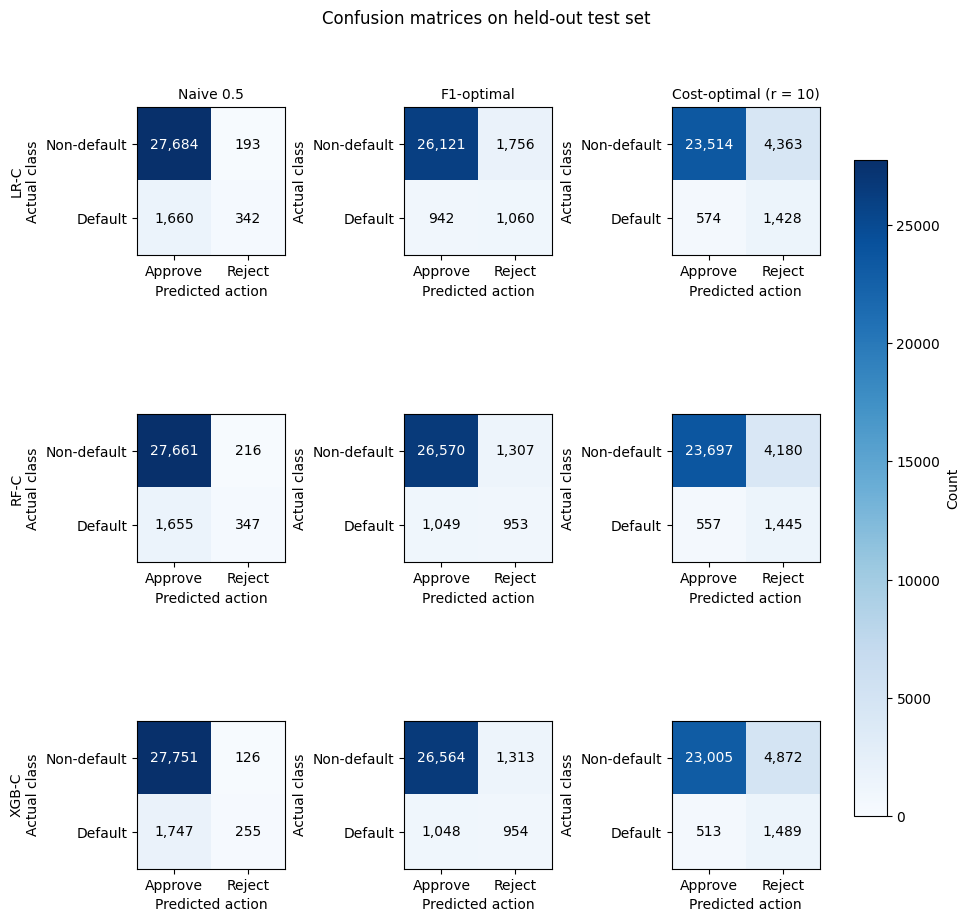

,Model,Threshold regime,Threshold,TN,FP,FN,TP
0,LR-C,Naive 0.5,0.5,"27,684",193,"1,660",342
1,LR-C,F1-optimal,0.19,"26,121","1,756",942,"1,060"
2,LR-C,Cost-optimal (r = 10),0.088,"23,514","4,363",574,"1,428"
3,RF-C,Naive 0.5,0.5,"27,661",216,"1,655",347
4,RF-C,F1-optimal,0.24,"26,570","1,307","1,049",953
5,RF-C,Cost-optimal (r = 10),0.086,"23,697","4,180",557,"1,445"
6,XGB-C,Naive 0.5,0.5,"27,751",126,"1,747",255
7,XGB-C,F1-optimal,0.23,"26,564","1,313","1,048",954
8,XGB-C,Cost-optimal (r = 10),0.084,"23,005","4,872",513,"1,489"


In [12]:
# Appendix Table 10 and Figure 3: confusion matrices on the held-out test set.
confusion_policies = [
    ('naive', 'Naive 0.5'),
    ('f1', 'F1-optimal'),
    ('cost_10', 'Cost-optimal (r = 10)'),
]
confusion_rows = []
for family in FAMILY_ORDER:
    key = SELECTED[family]
    p = test_probabilities[key]
    for policy, label in confusion_policies:
        if policy == 'naive':
            t = 0.5
        elif policy == 'f1':
            t = thresholds[key]['f1']
        else:
            t = thresholds[key]['cost_optimal']['10']
        counts = confusion_at(y_test, p, t)
        confusion_rows.append({
            'model': model_label(key),
            'model_key': key,
            'policy': policy,
            'policy_label': label,
            'threshold': t,
            **counts,
            'total': sum(counts.values()),
        })
confusion_csv = pd.DataFrame(confusion_rows)
confusion_md = pd.DataFrame({
    'Model': confusion_csv['model'],
    'Threshold regime': confusion_csv['policy_label'],
    'Threshold': confusion_csv['threshold'].map(fmt_trim),
    'TN': confusion_csv['TN'].map(fmt_count),
    'FP': confusion_csv['FP'].map(fmt_count),
    'FN': confusion_csv['FN'].map(fmt_count),
    'TP': confusion_csv['TP'].map(fmt_count),
})
export_table(
    'appendix_table_10_confusion_counts',
    confusion_csv,
    confusion_md,
    'Appendix Table 10. Numeric confusion-matrix counts on the held-out test set. Positive class = default; predicted default corresponds to rejection.'
)

vmax = int(confusion_csv[['TN', 'FP', 'FN', 'TP']].to_numpy().max())
fig, axes = plt.subplots(3, 3, figsize=(9.6, 9.2), constrained_layout=True)
for row_idx, family in enumerate(FAMILY_ORDER):
    key = SELECTED[family]
    for col_idx, (policy, label) in enumerate(confusion_policies):
        ax = axes[row_idx, col_idx]
        row = confusion_csv[(confusion_csv.model_key == key) & (confusion_csv.policy == policy)].iloc[0]
        matrix = np.array([[row.TN, row.FP], [row.FN, row.TP]], dtype=int)
        image = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=vmax)
        for (i, j), value in np.ndenumerate(matrix):
            color = 'white' if value > vmax * 0.45 else 'black'
            ax.text(j, i, f'{value:,}', ha='center', va='center', fontsize=10, color=color)
        if row_idx == 0:
            ax.set_title(label, fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(f'{model_label(key)}\nActual class')
        else:
            ax.set_ylabel('Actual class')
        ax.set_xlabel('Predicted action')
        ax.set_xticks([0, 1], ['Approve', 'Reject'])
        ax.set_yticks([0, 1], ['Non-default', 'Default'])
fig.colorbar(image, ax=axes, shrink=0.72, label='Count')
fig.suptitle('Confusion matrices on held-out test set', y=1.02)
fig.savefig(FIGURES_DIR / 'figure_03_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
confusion_md

In [13]:
# Contract checks: expected files, row counts, confusion totals, and key artifact spot checks.
main_tables = [
    'table_01_validation_discrimination',
    'table_02_validation_calibration',
    'table_03_thresholds',
    'table_04_test_metrics_expected_loss',
    'table_05_metric_rankings',
    'table_06_xgb_subgroup_approval',
]
appendix_tables = [f'appendix_table_{i:02d}_tier1_{dim}_{key}' for i, (dim, key) in enumerate([
    ('age', 'logreg_C'), ('age', 'rf_C'), ('age', 'xgb_C'),
    ('income', 'logreg_C'), ('income', 'rf_C'), ('income', 'xgb_C'),
    ('dependents', 'logreg_C'), ('dependents', 'rf_C'), ('dependents', 'xgb_C'),
], start=1)] + ['appendix_table_10_confusion_counts']
expected_table_files = sorted([f'{name}{suffix}' for name in main_tables + appendix_tables for suffix in ('.csv', '.md')])
expected_figure_files = sorted(['figure_02_corp_reliability_diagrams.png', 'figure_03_confusion_matrices.png'])
actual_table_files = sorted(p.name for p in TABLES_DIR.iterdir() if p.is_file())
actual_figure_files = sorted(p.name for p in FIGURES_DIR.iterdir() if p.is_file())
assert actual_table_files == expected_table_files, (actual_table_files, expected_table_files)
assert actual_figure_files == expected_figure_files, (actual_figure_files, expected_figure_files)

assert len(table1_csv) == 9
assert len(table2_csv) == 3
assert len(table3_csv) == 4
assert len(table4_csv) == 3
assert len(table6_csv) == 5
for idx, (dimension, key) in enumerate(appendix_order, start=1):
    expected_rows = {'age_group': 20, 'income_group': 15, 'dependents_group': 10}[dimension]
    assert len(tier1_lookup[(dimension, key)]) == expected_rows
assert (confusion_csv['total'] == len(y_test)).all()
assert len(y_test) == 29879
assert calibration['selected_calibrator']['rf_C'] == 'beta'
assert calibration['selected_calibrator']['xgb_C'] == 'isotonic'
assert subgroup_results['intersection']['n'] == 594

for ratio in COST_RATIOS:
    for key in SELECTED.values():
        artifact_el = cost[(cost.model == key) & (cost.policy == f'cost_{ratio}')].iloc[0][f'EL@{ratio}']
        exported_el = table4_csv[table4_csv.model_key == key].iloc[0][f'EL_at_{ratio}']
        assert np.isclose(artifact_el, exported_el)

print('Export contract passed.')
print('tables:', len(actual_table_files), 'files')
print('figures:', actual_figure_files)

Export contract passed.
tables: 32 files
figures: ['figure_02_corp_reliability_diagrams.png', 'figure_03_confusion_matrices.png']
